In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [3]:
files = ["M13_0001.fits",
         "M13_0002.fits",
         "M13_0003.fits",
         "M13_0004.fits",
         "M13_0005.fits"]

data_list = []

for f in files:
    with fits.open(f) as hdul:
        data = hdul[0].data
        data_list.append(data)

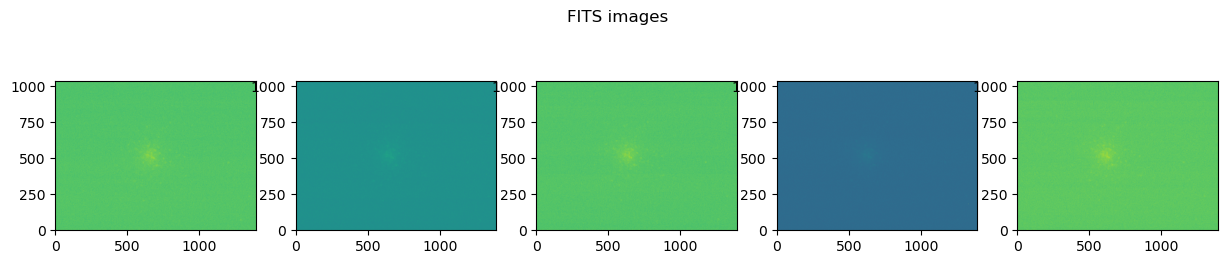

In [15]:
plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(data_list[i], origin="lower")

plt.suptitle("FITS images")
plt.show()


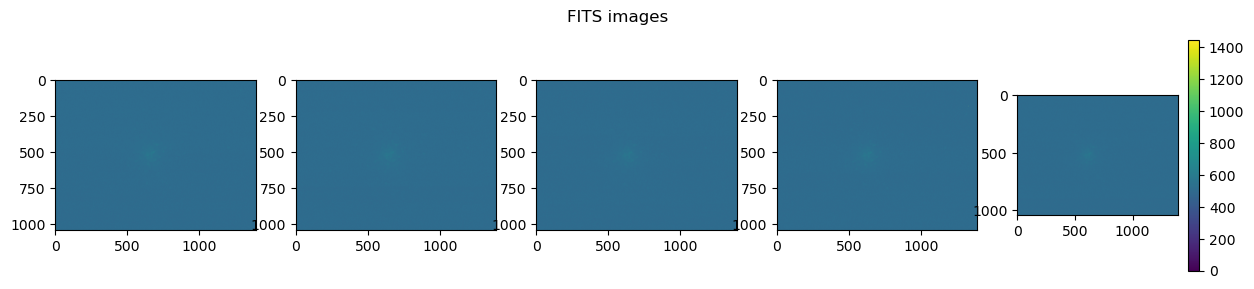

In [23]:
all_data = np.array(data_list)

vmin = np.min(all_data)
vmax = np.max(all_data)

plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    img = plt.imshow(data_list[i],cmap="viridis",vmin=vmin, vmax=vmax)

plt.suptitle("FITS images")
plt.colorbar(img)
plt.show()


In [24]:
#it is even harder to see

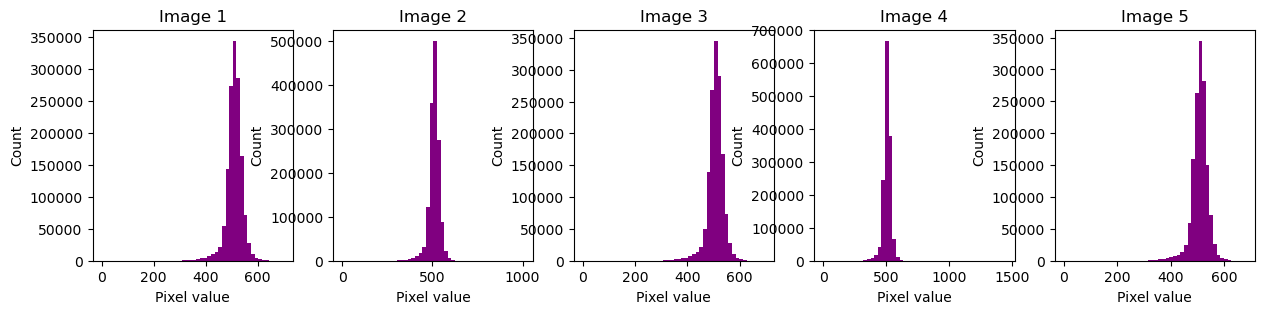

In [26]:
plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.hist(data_list[i].ravel(), bins=50, color="purple")
    plt.title(f"Image {i+1}")
    plt.xlabel("Pixel value")
    plt.ylabel("Count")

plt.show()


In [30]:
for i in range(5):
    d = data_list[i].ravel()
    mean_val = np.mean(d)
    median_val = np.median(d)
    
    print(mean_val, median_val)

510.4706668600796 512.0
509.7460150033157 511.0
508.0498729000884 510.0
507.90583554376656 509.0
508.7919920148099 510.0


In [31]:
#x-axis = pixel intensity
#y-axis = number of pixels
#bins=50 = data split into 50 groups
#Most data centered around background level
#Spread = not very wide; most values grouped near center
#Mean/median = printed by the loop

Median pixel intensity of combined image: 510.0


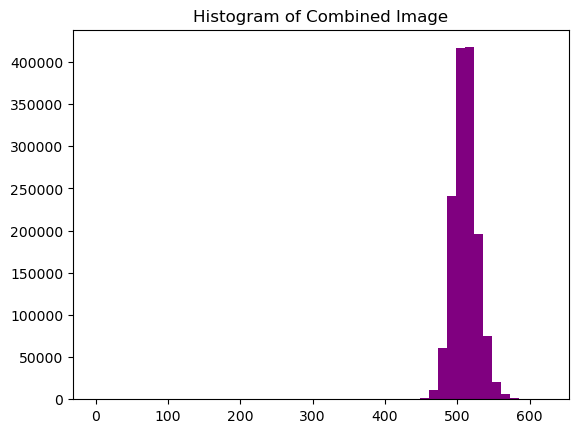

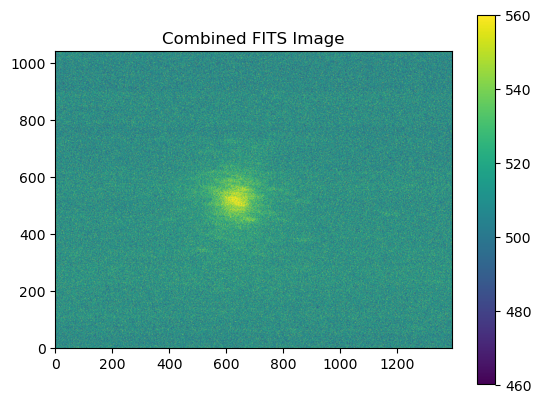

In [39]:
combined = np.median(np.array(data_list), axis=0)

median_val = np.median(combined)
print("Median pixel intensity of combined image:", median_val)

plt.hist(combined.ravel(), bins=50, color="purple")
plt.title("Histogram of Combined Image")
plt.show()

vmin = median_val - 50
vmax = median_val + 50

img = plt.imshow(combined, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
plt.colorbar(img)
plt.title("Combined FITS Image")
plt.show()

fits.writeto("combined.fits", combined, overwrite=True)

